In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data


In [22]:
import yfinance as yf

df = yf.download('AAPL', start='2010-01-01', end='2019-12-31')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417559,6.453781,6.383731,6.424145,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303802,6.346311,6.258001,6.338827,477131200
2010-01-08,6.345712,6.346311,6.258302,6.295421,447610800


In [32]:
df.tail()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-12-23,68.396263,68.456471,67.522042,67.560576,98572000
2019-12-24,68.461281,68.610603,68.136164,68.562433,48478800
2019-12-26,69.819580,69.836440,68.564848,68.593747,93121200
2019-12-27,69.793091,70.797363,69.388495,70.110991,146266000
2019-12-30,70.207321,70.489098,68.690083,69.711208,144114400


In [3]:
df=df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.406479,6.421148,6.357685,6.389117,493729600
1,2010-01-05,6.417558,6.453780,6.383730,6.424144,601904800
2,2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
3,2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
4,2010-01-08,6.345712,6.346311,6.258301,6.295420,447610800


In [4]:
df=df.drop(['Date'], axis=1)
df.head()

C:\Users\salin\AppData\Local\Temp\ipykernel_20088\2547152359.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop(['Date'], axis=1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.406479,6.421148,6.357685,6.389117,493729600
1,6.417558,6.453780,6.383730,6.424144,601904800
2,6.315477,6.443002,6.308891,6.417557,552160000
3,6.303801,6.346310,6.258000,6.338826,477131200
4,6.345712,6.346311,6.258301,6.295420,447610800


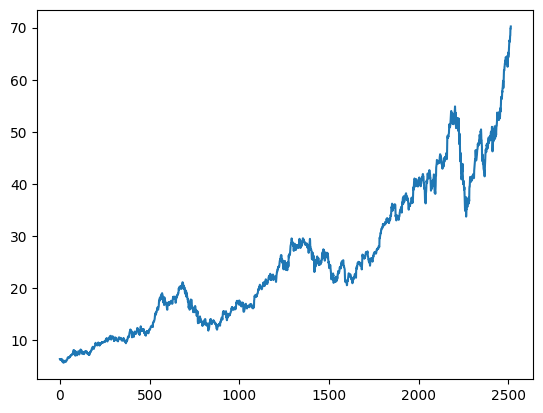

In [35]:
plt.plot(df.Close)

In [36]:
ma100 = df.Close.rolling(100).mean()
ma100


Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,56.912129
2511,57.108721
2512,57.344444
2513,57.571146


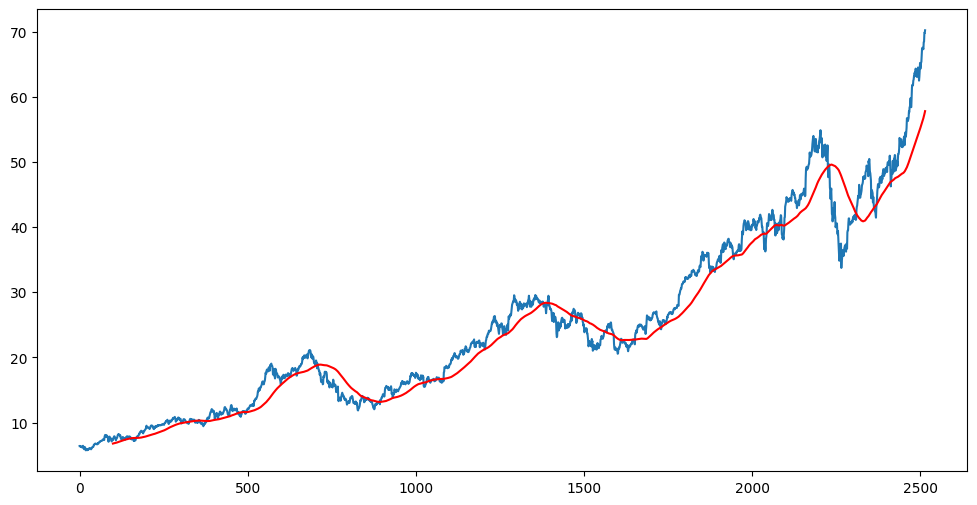

In [37]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

In [38]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,51.890290
2511,52.017056
2512,52.149660
2513,52.279726


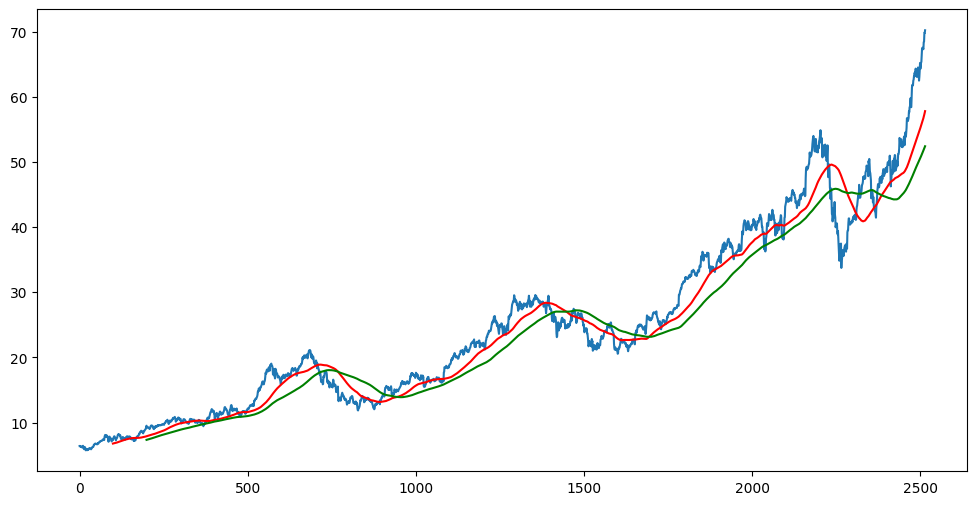

In [39]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [40]:
df.shape

(2515, 5)

In [13]:
df_close = pd.DataFrame(df['Close'].values,
                        index=df.index,
                        columns=['Close'])

In [14]:
# Splitting Data into Training and Testing
data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)


(1760, 1)
(755, 1)


In [9]:
data_training.head()


Ticker,AAPL
0,6.406479
1,6.417558
2,6.315477
3,6.303801
4,6.345712


In [10]:
data_testing.head()


Ticker,AAPL
1760,26.854670
1761,26.645315
1762,26.721237
1763,26.691322
1764,26.827066


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [16]:
data_training_array=scaler.fit_transform(data_training)
data_training_array


array([[0.02760005],
       [0.02806516],
       [0.0237793 ],
       ...,
       [0.88408399],
       [0.89123173],
       [0.88640221]], shape=(1760, 1))

In [47]:
data_training_array.shape

(1760, 1)

In [17]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train , y_train=np.array(x_train), np.array(y_train)

In [49]:
print(x_train.shape)
print(y_train.shape)

(1660, 100, 1)
(1660,)


In [50]:
# ML MODEL

In [7]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [33]:
model=Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(60, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(80, return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(120))
model.add(Dropout(0.5))

model.add(Dense(1))

C:\Users\salin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [34]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 299ms/step - loss: 0.0315
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 393ms/step - loss: 0.0082
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 390ms/step - loss: 0.0066
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 399ms/step - loss: 0.0073
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 413ms/step - loss: 0.0063
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 399ms/step - loss: 0.0055
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 367ms/step - loss: 0.0061
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 424ms/step - loss: 0.0052
Epoch 9/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 409ms/step - loss: 0.0054
Epoch 10/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 406ms/step - loss: 0.0056
Epoch 11/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 293ms/step - loss: 0.0051
Epoch 12/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - loss: 0.0044
Epoch 13/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - loss: 0.0044
Epoch 14/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - loss: 0.0045
Epoch 15/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [36]:
model.save('keras_model.keras')

In [37]:
data_testing.head()

Ticker,AAPL
Date,
2016-12-29,26.854673
2016-12-30,26.645317
2017-01-03,26.721241
2017-01-04,26.691330
2017-01-05,26.827065


In [38]:
data_training.tail(100)

Ticker,AAPL
Date,
2016-08-08,24.804031
2016-08-09,24.904743
2016-08-10,24.719345
2016-08-11,24.703327
2016-08-12,24.760546
...,...
2016-12-21,26.930584
2016-12-22,26.753445
2016-12-23,26.806353


In [39]:
past_100_days=data_training.tail(100)

In [40]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [41]:
final_df.head()

Ticker,AAPL
0,24.804031
1,24.904743
2,24.719345
3,24.703327
4,24.760546


In [42]:
input_data = scaler.transform(final_df)
input_data

array([[0.80001699],
       [0.80424535],
       [0.79646145],
       [0.79578895],
       [0.79819125],
       [0.81068423],
       [0.80972272],
       [0.80818535],
       [0.80684001],
       [0.80953068],
       [0.80136257],
       [0.80462989],
       [0.7967499 ],
       [0.79232943],
       [0.78627549],
       [0.78512226],
       [0.77724259],
       [0.77820339],
       [0.78425756],
       [0.79386696],
       [0.79357859],
       [0.79992113],
       [0.77262977],
       [0.74966286],
       [0.77186124],
       [0.79598114],
       [0.8326897 ],
       [0.86920624],
       [0.86296011],
       [0.85008323],
       [0.84998698],
       [0.84979487],
       [0.86007725],
       [0.84172284],
       [0.84335623],
       [0.84537431],
       [0.85363853],
       [0.83662978],
       [0.84498993],
       [0.83989711],
       [0.84450993],
       [0.84498993],
       [0.85306211],
       [0.85469566],
       [0.87381906],
       [0.87622137],
       [0.88621506],
       [0.882

In [43]:
input_data.shape

(855, 1)

In [44]:
x_test=[]
y_test=[]

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [45]:
x_test,y_test=np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(755, 100, 1)
(755,)


In [46]:
# Making Predictions

y_predicted=model.predict(x_test)
print(y_predicted.shape)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step
(755, 1)


In [47]:
y_predicted.shape

(755, 1)

In [48]:
y_test

array([0.88611272, 0.87732295, 0.88051059, 0.87925479, 0.88495357,
       0.89751029, 0.90794186, 0.90910093, 0.91528276, 0.91045308,
       0.90842474, 0.91769716, 0.91760058, 0.91557224, 0.91769716,
       0.91847008, 0.91740759, 0.935856  , 0.93643562, 0.93653228,
       0.93344128, 0.93073692, 1.00221284, 1.00008809, 1.00540049,
       1.01708746, 1.02906505, 1.03399066, 1.0432067 , 1.04029605,
       1.05164661, 1.06842889, 1.07318178, 1.07163024, 1.07521924,
       1.08472629, 1.08870361, 1.08307681, 1.08433799, 1.08695715,
       1.08753949, 1.11470145, 1.10664976, 1.11460487, 1.11033615,
       1.11208204, 1.10703783, 1.10393378, 1.10839582, 1.10897848,
       1.10694077, 1.12120151, 1.1234322 , 1.11664161, 1.13090171,
       1.11518705, 1.1305138 , 1.12566322, 1.1229474 , 1.12527532,
       1.15360187, 1.15670608, 1.15486264, 1.1522442 , 1.15263163,
       1.16301202, 1.15573599, 1.1522442 , 1.14913968, 1.14749084,
       1.13255135, 1.13420019, 1.12692464, 1.1344912 , 1.12837

In [49]:
y_predicted

array([[0.8772701 ],
       [0.8806132 ],
       [0.8833282 ],
       [0.8853831 ],
       [0.8867922 ],
       [0.88765967],
       [0.8882164 ],
       [0.8887603 ],
       [0.8895272 ],
       [0.8906945 ],
       [0.892292  ],
       [0.894238  ],
       [0.8964764 ],
       [0.89892864],
       [0.9014816 ],
       [0.9040345 ],
       [0.9065021 ],
       [0.90880597],
       [0.9110348 ],
       [0.9132842 ],
       [0.91560614],
       [0.9179748 ],
       [0.920305  ],
       [0.92308605],
       [0.92672765],
       [0.9314594 ],
       [0.9373652 ],
       [0.9444181 ],
       [0.95245576],
       [0.96125567],
       [0.97047985],
       [0.9798403 ],
       [0.98918796],
       [0.9984075 ],
       [1.0073417 ],
       [1.0158411 ],
       [1.0238354 ],
       [1.0312916 ],
       [1.038122  ],
       [1.0442501 ],
       [1.0496418 ],
       [1.0542952 ],
       [1.0584538 ],
       [1.0622746 ],
       [1.0659083 ],
       [1.0693991 ],
       [1.072745  ],
       [1.075

In [50]:
scaler.scale_

array([0.04198477])

In [51]:

y_predicted = model.predict(x_test)

y_predicted = scaler.inverse_transform(y_predicted)
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


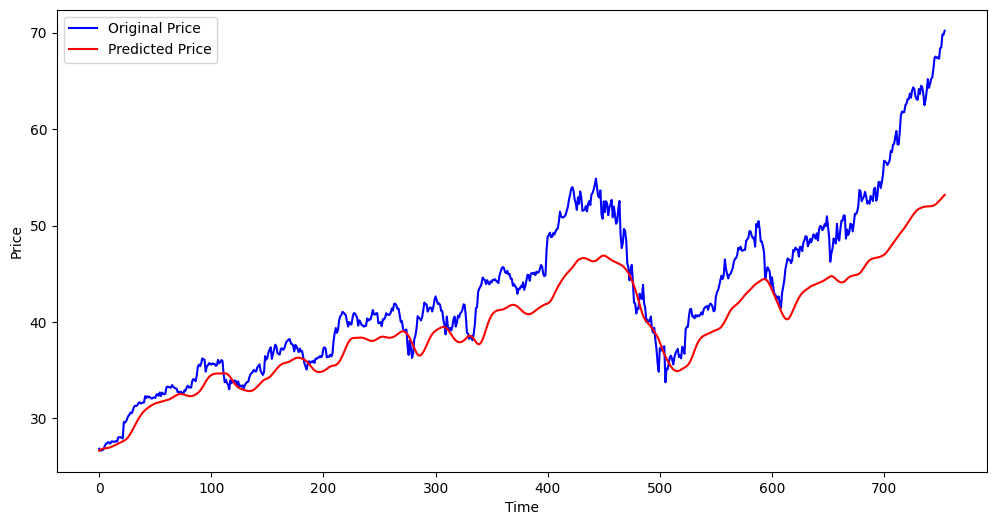

In [52]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [44]:
print(y_test)
print(y_predicted)

[[26.85467148]
 [26.64531708]
 [26.72123528]
 [26.69132805]
 [26.82706261]
 [27.12613869]
 [27.37459946]
 [27.40220833]
 [27.5494442 ]
 [27.43441772]
 [27.38610268]
 [27.60696411]
 [27.60466194]
 [27.55635071]
 [27.60696411]
 [27.62536812]
 [27.60006142]
 [28.03947067]
 [28.05327797]
 [28.0555706 ]
 [27.98194885]
 [27.9175415 ]
 [29.61996651]
 [29.56934929]
 [29.69588661]
 [29.97426224]
 [30.25952911]
 [30.37685013]
 [30.59635735]
 [30.5270443 ]
 [30.79737663]
 [31.19711876]
 [31.31032372]
 [31.27335739]
 [31.35884476]
 [31.58527374]
 [31.68000984]
 [31.54599953]
 [31.57603836]
 [31.63842201]
 [31.65228653]
 [32.29924393]
 [32.10746384]
 [32.29692459]
 [32.19526672]
 [32.23685074]
 [32.11670303]
 [32.04275513]
 [32.14904785]
 [32.16291046]
 [32.11439896]
 [32.45404816]
 [32.50717926]
 [32.34545135]
 [32.685112  ]
 [32.3107872 ]
 [32.67585754]
 [32.56032562]
 [32.4956398 ]
 [32.55109406]
 [33.22578049]
 [33.29970551]
 [33.2558136 ]
 [33.1934166 ]
 [33.20266724]
 [33.44989395]
 [33.27660

In [32]:
print(y_predicted[:10])
print(y_test[:10])

[[5.906677 ]
 [5.907328 ]
 [5.907909 ]
 [5.908407 ]
 [5.90882  ]
 [5.9091535]
 [5.9094315]
 [5.9097   ]
 [5.9099917]
 [5.910331 ]]
[[26.85467339]
 [26.64531708]
 [26.721241  ]
 [26.69132996]
 [26.82706451]
 [27.1261425 ]
 [27.37460327]
 [27.40221024]
 [27.54944992]
 [27.43441582]]
